# Telecom Churn Case Study
With 21 predictor variables we need to predict weather a particular customer will switch to another telecom provider or not.
In telecom terminology, this is refered as churning and not churning,respectively!!!

### Step-1: Importing and merging data

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
churn_data=pd.read_csv("churn_data.csv")
churn_data.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
customer_data=pd.read_csv("customer_data.csv")
customer_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [4]:
internet_data=pd.read_csv("internet_data.csv")
internet_data.head()

,customerID,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,No,Fiber optic,No,No,No,No,No,No


### Step-2: merge the dataframes

In [5]:
df1=pd.merge(churn_data,customer_data,how="inner",on="customerID")

In [6]:
telecom=pd.merge(df1,internet_data,how="inner",on="customerID")

In [7]:
telecom.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,...,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,1,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Female,...,Yes,No,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,34,Yes,One year,No,Mailed check,56.95,1889.5,No,Male,...,No,No,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,2,Yes,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Male,...,No,No,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,45,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Male,...,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,2,Yes,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Female,...,No,No,No,Fiber optic,No,No,No,No,No,No


In [8]:
telecom.columns

Index(['customerID', 'tenure', 'PhoneService', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender',
       'SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies'],
      dtype='object')

In [9]:
telecom.shape

(7043, 21)

In [10]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   tenure            7043 non-null   int64  
 2   PhoneService      7043 non-null   object 
 3   Contract          7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   Churn             7043 non-null   object 
 9   gender            7043 non-null   object 
 10  SeniorCitizen     7043 non-null   int64  
 11  Partner           7043 non-null   object 
 12  Dependents        7043 non-null   object 
 13  MultipleLines     7043 non-null   object 
 14  InternetService   7043 non-null   object 
 15  OnlineSecurity    7043 non-null   object 
 16  OnlineBackup      7043 non-null   object 


In [11]:
telecom.describe()

,tenure,MonthlyCharges,SeniorCitizen
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,0.162147
std,24.559481,30.090047,0.368612
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,0.000000
50%,29.000000,70.350000,0.000000
75%,55.000000,89.850000,0.000000
max,72.000000,118.750000,1.000000


### Step-3: Data Preparation

#### converting binary variables "Yes/No" to 0/1

In [12]:
varlist=["PhoneService","PaperlessBilling","Churn","Partner","Dependents"]
telecom[varlist]=telecom[varlist].apply(lambda x:x.map({"Yes":1,"No":0}))

In [13]:
telecom.head()

,customerID,tenure,PhoneService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,gender,...,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,1,0,Month-to-month,1,Electronic check,29.85,29.85,0,Female,...,1,0,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,34,1,One year,0,Mailed check,56.95,1889.5,0,Male,...,0,0,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,2,1,Month-to-month,1,Mailed check,53.85,108.15,1,Male,...,0,0,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,45,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,Male,...,0,0,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,2,1,Month-to-month,1,Electronic check,70.70,151.65,1,Female,...,0,0,No,Fiber optic,No,No,No,No,No,No


In [14]:
#getting the dummy variables
dummy1=pd.get_dummies(telecom[["Contract","PaymentMethod","gender","InternetService"]],drop_first=True)
telecom=pd.concat([telecom,dummy1],axis=1)
telecom=telecom.drop(["Contract","PaymentMethod","gender","InternetService"],axis=1)

In [15]:
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,StreamingTV,StreamingMovies,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,No,No,False,False,False,True,False,False,False,False
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,No,No,True,False,False,False,True,True,False,False
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,No,No,False,False,False,False,True,True,False,False
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,No,No,True,False,False,False,False,True,False,False
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,No,No,False,False,False,True,False,False,True,False


In [16]:
telecom.shape

(7043, 25)

In [17]:
telecom.columns

Index(['customerID', 'tenure', 'PhoneService', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'SeniorCitizen', 'Partner',
       'Dependents', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'gender_Male', 'InternetService_Fiber optic', 'InternetService_No'],
      dtype='object')

In [18]:
lst=['Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'gender_Male', 'InternetService_Fiber optic', 'InternetService_No']
telecom[lst]=telecom[lst].apply(lambda x:x.map({True:1,False:0}))

In [19]:
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,StreamingTV,StreamingMovies,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,No,No,0,0,0,1,0,0,0,0
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,No,No,1,0,0,0,1,1,0,0
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,No,No,0,0,0,0,1,1,0,0
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,No,No,1,0,0,0,0,1,0,0
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,No,No,0,0,0,1,0,0,1,0


In [20]:
telecom["OnlineBackup"].value_counts()
#telecom["TechSupport"].value_counts()
#telecom["StreamingTV"].value_counts()


OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

In [21]:
ml=pd.get_dummies(telecom["MultipleLines"],prefix="MultipleLines")
ml1=ml.drop(["MultipleLines_No phone service"],axis=1)
telecom=pd.concat([telecom,ml1],axis=1)
#drop "MultipleLines" column

In [22]:
ml1.head()

,MultipleLines_No,MultipleLines_Yes
0,False,False
1,True,False
2,True,False
3,False,False
4,True,False


In [23]:
telecom[ml1]=ml1.apply(lambda x:x.map({True:1,False:0}))

In [24]:
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No,MultipleLines_No,MultipleLines_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,0,0,0,1,0,0,0,0,False,False
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,1,0,0,0,1,1,0,0,1,False
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,0,0,0,0,1,1,0,0,1,False
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,1,0,0,0,0,1,0,0,False,False
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,0,0,0,1,0,0,1,0,1,False


In [25]:
os=pd.get_dummies(telecom["OnlineSecurity"],prefix="OnlineSecurity")
os1=os.drop(["OnlineSecurity_No internet service"],axis=1)
telecom=pd.concat([telecom,os1],axis=1)

In [26]:
os1.head()

,OnlineSecurity_No,OnlineSecurity_Yes
0,True,False
1,False,True
2,False,True
3,False,True
4,True,False


In [27]:
telecom[os1.columns]=os1.apply(lambda x:x.map({True:1,False:0}))

In [28]:
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No,MultipleLines_No,MultipleLines_Yes,OnlineSecurity_No,OnlineSecurity_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,0,1,0,0,0,0,False,False,1,0
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,0,0,1,1,0,0,1,False,0,1
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,0,0,1,1,0,0,1,False,0,1
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,0,0,0,1,0,0,False,False,0,1
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,0,1,0,0,1,0,1,False,1,0


In [29]:
ob=pd.get_dummies(telecom["OnlineBackup"],prefix="OnlineBackup")

In [30]:
print(ob.columns)

Index(['OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes'],
      dtype='object')


In [31]:
ob1=ob.drop(['OnlineBackup_No internet service'],axis=1)
telecom=pd.concat([telecom,ob1],axis=1)

In [32]:
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No,MultipleLines_No,MultipleLines_Yes,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,0,0,0,0,False,False,1,0,False,True
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,1,1,0,0,1,False,0,1,True,False
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,1,1,0,0,1,False,0,1,False,True
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,0,1,0,0,False,False,0,1,True,False
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,0,0,1,0,1,False,1,0,True,False


In [33]:
telecom[ob1.columns]=ob1.apply(lambda x:x.map({True:1,False:0}))
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,PaymentMethod_Mailed check,gender_Male,InternetService_Fiber optic,InternetService_No,MultipleLines_No,MultipleLines_Yes,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,0,0,0,0,False,False,1,0,0,1
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,1,1,0,0,1,False,0,1,1,0
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,1,1,0,0,1,False,0,1,0,1
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,0,1,0,0,False,False,0,1,1,0
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,0,0,1,0,1,False,1,0,1,0


In [34]:
dp=pd.get_dummies(telecom["DeviceProtection"],prefix="DeviceProtection")
dp.columns

Index(['DeviceProtection_No', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes'],
      dtype='object')

In [35]:
dp1=dp.drop(['DeviceProtection_No internet service'],axis=1)
telecom=pd.concat([telecom,dp1],axis=1)
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,InternetService_Fiber optic,InternetService_No,MultipleLines_No,MultipleLines_Yes,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,0,0,False,False,1,0,0,1,True,False
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,0,0,1,False,0,1,1,0,False,True
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,0,0,1,False,0,1,0,1,True,False
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,0,0,False,False,0,1,1,0,False,True
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,1,0,1,False,1,0,1,0,True,False


In [36]:
telecom[dp1.columns]=dp1.apply(lambda x:x.map({True:1,False:0}))
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,InternetService_Fiber optic,InternetService_No,MultipleLines_No,MultipleLines_Yes,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,0,0,False,False,1,0,0,1,1,0
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,0,0,1,False,0,1,1,0,0,1
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,0,0,1,False,0,1,0,1,1,0
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,0,0,False,False,0,1,1,0,0,1
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,1,0,1,False,1,0,1,0,1,0


In [37]:
ts=pd.get_dummies(telecom["TechSupport"],prefix="TechSupport")
ts1=ts.drop(['TechSupport_No internet service'],axis=1)

In [38]:
telecom=pd.concat([telecom,ts1],axis=1)

In [39]:
telecom[ts1.columns]=ts1.apply(lambda x:x.map({True:1,False:0}))
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,MultipleLines_No,MultipleLines_Yes,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,False,False,1,0,0,1,1,0,1,0
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,1,False,0,1,1,0,0,1,1,0
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,1,False,0,1,0,1,1,0,1,0
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,False,False,0,1,1,0,0,1,0,1
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,1,False,1,0,1,0,1,0,1,0


In [40]:
st=pd.get_dummies(telecom["StreamingTV"],prefix="StreamingTV")
st1=st.drop(["StreamingTV_No internet service"],axis=1)

In [41]:
telecom=pd.concat([telecom,st1],axis=1)
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,1,0,0,1,1,0,1,0,True,False
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,0,1,1,0,0,1,1,0,True,False
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,0,1,0,1,1,0,1,0,True,False
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,0,1,1,0,0,1,0,1,True,False
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,1,0,1,0,1,0,1,0,True,False


In [42]:
telecom[st1.columns]=st1.apply(lambda x:x.map({True:1,False:0}))
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,OnlineSecurity_No,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,1,0,0,1,1,0,1,0,1,0
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,0,1,1,0,0,1,1,0,1,0
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,0,1,0,1,1,0,1,0,1,0
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,0,1,1,0,0,1,0,1,1,0
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,1,0,1,0,1,0,1,0,1,0


In [43]:
sm=pd.get_dummies(telecom["StreamingMovies"],prefix="StreamingMovies")
sm1=sm.drop(["StreamingMovies_No internet service"],axis=1)

In [44]:
telecom=pd.concat([telecom,sm1],axis=1)
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,0,1,1,0,1,0,1,0,True,False
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,1,0,0,1,1,0,1,0,True,False
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,0,1,1,0,1,0,1,0,True,False
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,1,0,0,1,0,1,1,0,True,False
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,1,0,1,0,1,0,1,0,True,False


In [45]:
telecom[sm1.columns]=sm1.apply(lambda x:x.map({True:1,False:0}))
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,0,1,1,0,1,0,1,0,1,0
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,1,0,0,1,1,0,1,0,1,0
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,0,1,1,0,1,0,1,0,1,0
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,1,0,0,1,0,1,1,0,1,0
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,1,0,1,0,1,0,1,0,1,0


In [46]:
telecom=telecom.drop(["MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"],axis=1)
telecom.head()

,customerID,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,SeniorCitizen,Partner,Dependents,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,7590-VHVEG,1,0,1,29.85,29.85,0,0,1,0,...,0,1,1,0,1,0,1,0,1,0
1,5575-GNVDE,34,1,0,56.95,1889.5,0,0,0,0,...,1,0,0,1,1,0,1,0,1,0
2,3668-QPYBK,2,1,1,53.85,108.15,1,0,0,0,...,0,1,1,0,1,0,1,0,1,0
3,7795-CFOCW,45,0,0,42.30,1840.75,0,0,0,0,...,1,0,0,1,0,1,1,0,1,0
4,9237-HQITU,2,1,1,70.70,151.65,1,0,0,0,...,1,0,1,0,1,0,1,0,1,0


In [47]:
telecom.shape

(7043, 32)

In [48]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   tenure                                 7043 non-null   int64  
 2   PhoneService                           7043 non-null   int64  
 3   PaperlessBilling                       7043 non-null   int64  
 4   MonthlyCharges                         7043 non-null   float64
 5   TotalCharges                           7043 non-null   object 
 6   Churn                                  7043 non-null   int64  
 7   SeniorCitizen                          7043 non-null   int64  
 8   Partner                                7043 non-null   int64  
 9   Dependents                             7043 non-null   int64  
 10  Contract_One year                      7043 non-null   int64  
 11  Cont

In [49]:
#since "TotalCharges" data type was object change it to int
telecom["TotalCharges"] = pd.to_numeric(telecom["TotalCharges"], errors="coerce")

In [50]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   tenure                                 7043 non-null   int64  
 2   PhoneService                           7043 non-null   int64  
 3   PaperlessBilling                       7043 non-null   int64  
 4   MonthlyCharges                         7043 non-null   float64
 5   TotalCharges                           7032 non-null   float64
 6   Churn                                  7043 non-null   int64  
 7   SeniorCitizen                          7043 non-null   int64  
 8   Partner                                7043 non-null   int64  
 9   Dependents                             7043 non-null   int64  
 10  Contract_One year                      7043 non-null   int64  
 11  Cont

In [51]:
telecom.shape

(7043, 32)

In [52]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerID                             7043 non-null   object 
 1   tenure                                 7043 non-null   int64  
 2   PhoneService                           7043 non-null   int64  
 3   PaperlessBilling                       7043 non-null   int64  
 4   MonthlyCharges                         7043 non-null   float64
 5   TotalCharges                           7032 non-null   float64
 6   Churn                                  7043 non-null   int64  
 7   SeniorCitizen                          7043 non-null   int64  
 8   Partner                                7043 non-null   int64  
 9   Dependents                             7043 non-null   int64  
 10  Contract_One year                      7043 non-null   int64  
 11  Cont

### check outliers

In [53]:
num_tele=telecom[["tenure","MonthlyCharges","SeniorCitizen","TotalCharges"]]#take this colms from 1st info()
num_tele.describe(percentiles=[.25,.5,.75,.90,.95,.99])

,tenure,MonthlyCharges,SeniorCitizen,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,0.162147,2283.300441
std,24.559481,30.090047,0.368612,2266.771362
min,0.000000,18.250000,0.000000,18.800000
25%,9.000000,35.500000,0.000000,401.450000
50%,29.000000,70.350000,0.000000,1397.475000
75%,55.000000,89.850000,0.000000,3794.737500
90%,69.000000,102.600000,1.000000,5976.640000
95%,72.000000,107.400000,1.000000,6923.590000
99%,72.000000,114.729000,1.000000,8039.883000


In [54]:
telecom.isnull().sum()

customerID                                0
tenure                                    0
PhoneService                              0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
SeniorCitizen                             0
Partner                                   0
Dependents                                0
Contract_One year                         0
Contract_Two year                         0
PaymentMethod_Credit card (automatic)     0
PaymentMethod_Electronic check            0
PaymentMethod_Mailed check                0
gender_Male                               0
InternetService_Fiber optic               0
InternetService_No                        0
MultipleLines_No                          0
MultipleLines_Yes                         0
OnlineSecurity_No                         0
OnlineSecurity_Yes                        0
OnlineBackup_No                 

In [55]:
#checking null percent in dataset!
round(100*telecom.isnull().sum()/len(telecom.index),2)

customerID                               0.00
tenure                                   0.00
PhoneService                             0.00
PaperlessBilling                         0.00
MonthlyCharges                           0.00
TotalCharges                             0.16
Churn                                    0.00
SeniorCitizen                            0.00
Partner                                  0.00
Dependents                               0.00
Contract_One year                        0.00
Contract_Two year                        0.00
PaymentMethod_Credit card (automatic)    0.00
PaymentMethod_Electronic check           0.00
PaymentMethod_Mailed check               0.00
gender_Male                              0.00
InternetService_Fiber optic              0.00
InternetService_No                       0.00
MultipleLines_No                         0.00
MultipleLines_Yes                        0.00
OnlineSecurity_No                        0.00
OnlineSecurity_Yes                

In [56]:
#removing rows having null values based on "TotalCharges"!
telecom=telecom[~np.isnan(telecom["TotalCharges"])]
telecom.isnull().sum()
telecom.shape

(7032, 32)

In [57]:
#Again calculate percentage of missing values!!!
round(100*(telecom.isnull().sum())/(len(telecom.index)),2)

customerID                               0.0
tenure                                   0.0
PhoneService                             0.0
PaperlessBilling                         0.0
MonthlyCharges                           0.0
TotalCharges                             0.0
Churn                                    0.0
SeniorCitizen                            0.0
Partner                                  0.0
Dependents                               0.0
Contract_One year                        0.0
Contract_Two year                        0.0
PaymentMethod_Credit card (automatic)    0.0
PaymentMethod_Electronic check           0.0
PaymentMethod_Mailed check               0.0
gender_Male                              0.0
InternetService_Fiber optic              0.0
InternetService_No                       0.0
MultipleLines_No                         0.0
MultipleLines_Yes                        0.0
OnlineSecurity_No                        0.0
OnlineSecurity_Yes                       0.0
OnlineBack

### Step-4: Train-test-split

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X=telecom.drop(["Churn","customerID"],axis=1)
y=telecom['Churn']

In [60]:
#Note:- why customer-id must be dropped?
#because it is unique for each customer and though the model learns the id it may fail to predict churn for the test set by using the cust_id because it had never seen in the training set

In [61]:
X.head()

,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,SeniorCitizen,Partner,Dependents,Contract_One year,Contract_Two year,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
0,1,0,1,29.85,29.85,0,1,0,0,0,...,0,1,1,0,1,0,1,0,1,0
1,34,1,0,56.95,1889.50,0,0,0,1,0,...,1,0,0,1,1,0,1,0,1,0
2,2,1,1,53.85,108.15,0,0,0,0,0,...,0,1,1,0,1,0,1,0,1,0
3,45,0,0,42.30,1840.75,0,0,0,1,0,...,1,0,0,1,0,1,1,0,1,0
4,2,1,1,70.70,151.65,0,0,0,0,0,...,1,0,1,0,1,0,1,0,1,0


In [62]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [63]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7,test_size=0.3,random_state=100)

### step-5: Feature scaling

In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
scaler=StandardScaler()
X_train[["tenure","MonthlyCharges","TotalCharges"]]=scaler.fit_transform(X_train[["tenure","MonthlyCharges","TotalCharges"]])
X_train.head()

,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,SeniorCitizen,Partner,Dependents,Contract_One year,Contract_Two year,...,OnlineBackup_No,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_Yes,TechSupport_No,TechSupport_Yes,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes
879,0.019693,1,1,-0.338074,-0.276449,0,0,0,0,0,...,0,1,1,0,1,0,1,0,1,0
5790,0.305384,0,1,-0.464443,-0.112702,0,1,1,0,0,...,0,1,1,0,1,0,0,1,0,1
6498,-1.286319,1,1,0.581425,-0.974430,0,0,0,0,0,...,0,1,0,1,1,0,1,0,1,0
880,-0.919003,1,1,1.505913,-0.550676,0,0,0,0,0,...,0,1,0,1,0,1,0,1,0,1
2784,-1.163880,1,1,1.106854,-0.835971,0,0,1,0,0,...,1,0,0,1,0,1,0,1,0,1


In [66]:
churn=(sum(telecom["Churn"])/len(telecom["Churn"].index))*100
churn

26.578498293515356

In [67]:
telecom["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

### Look the correlation b/w the variables

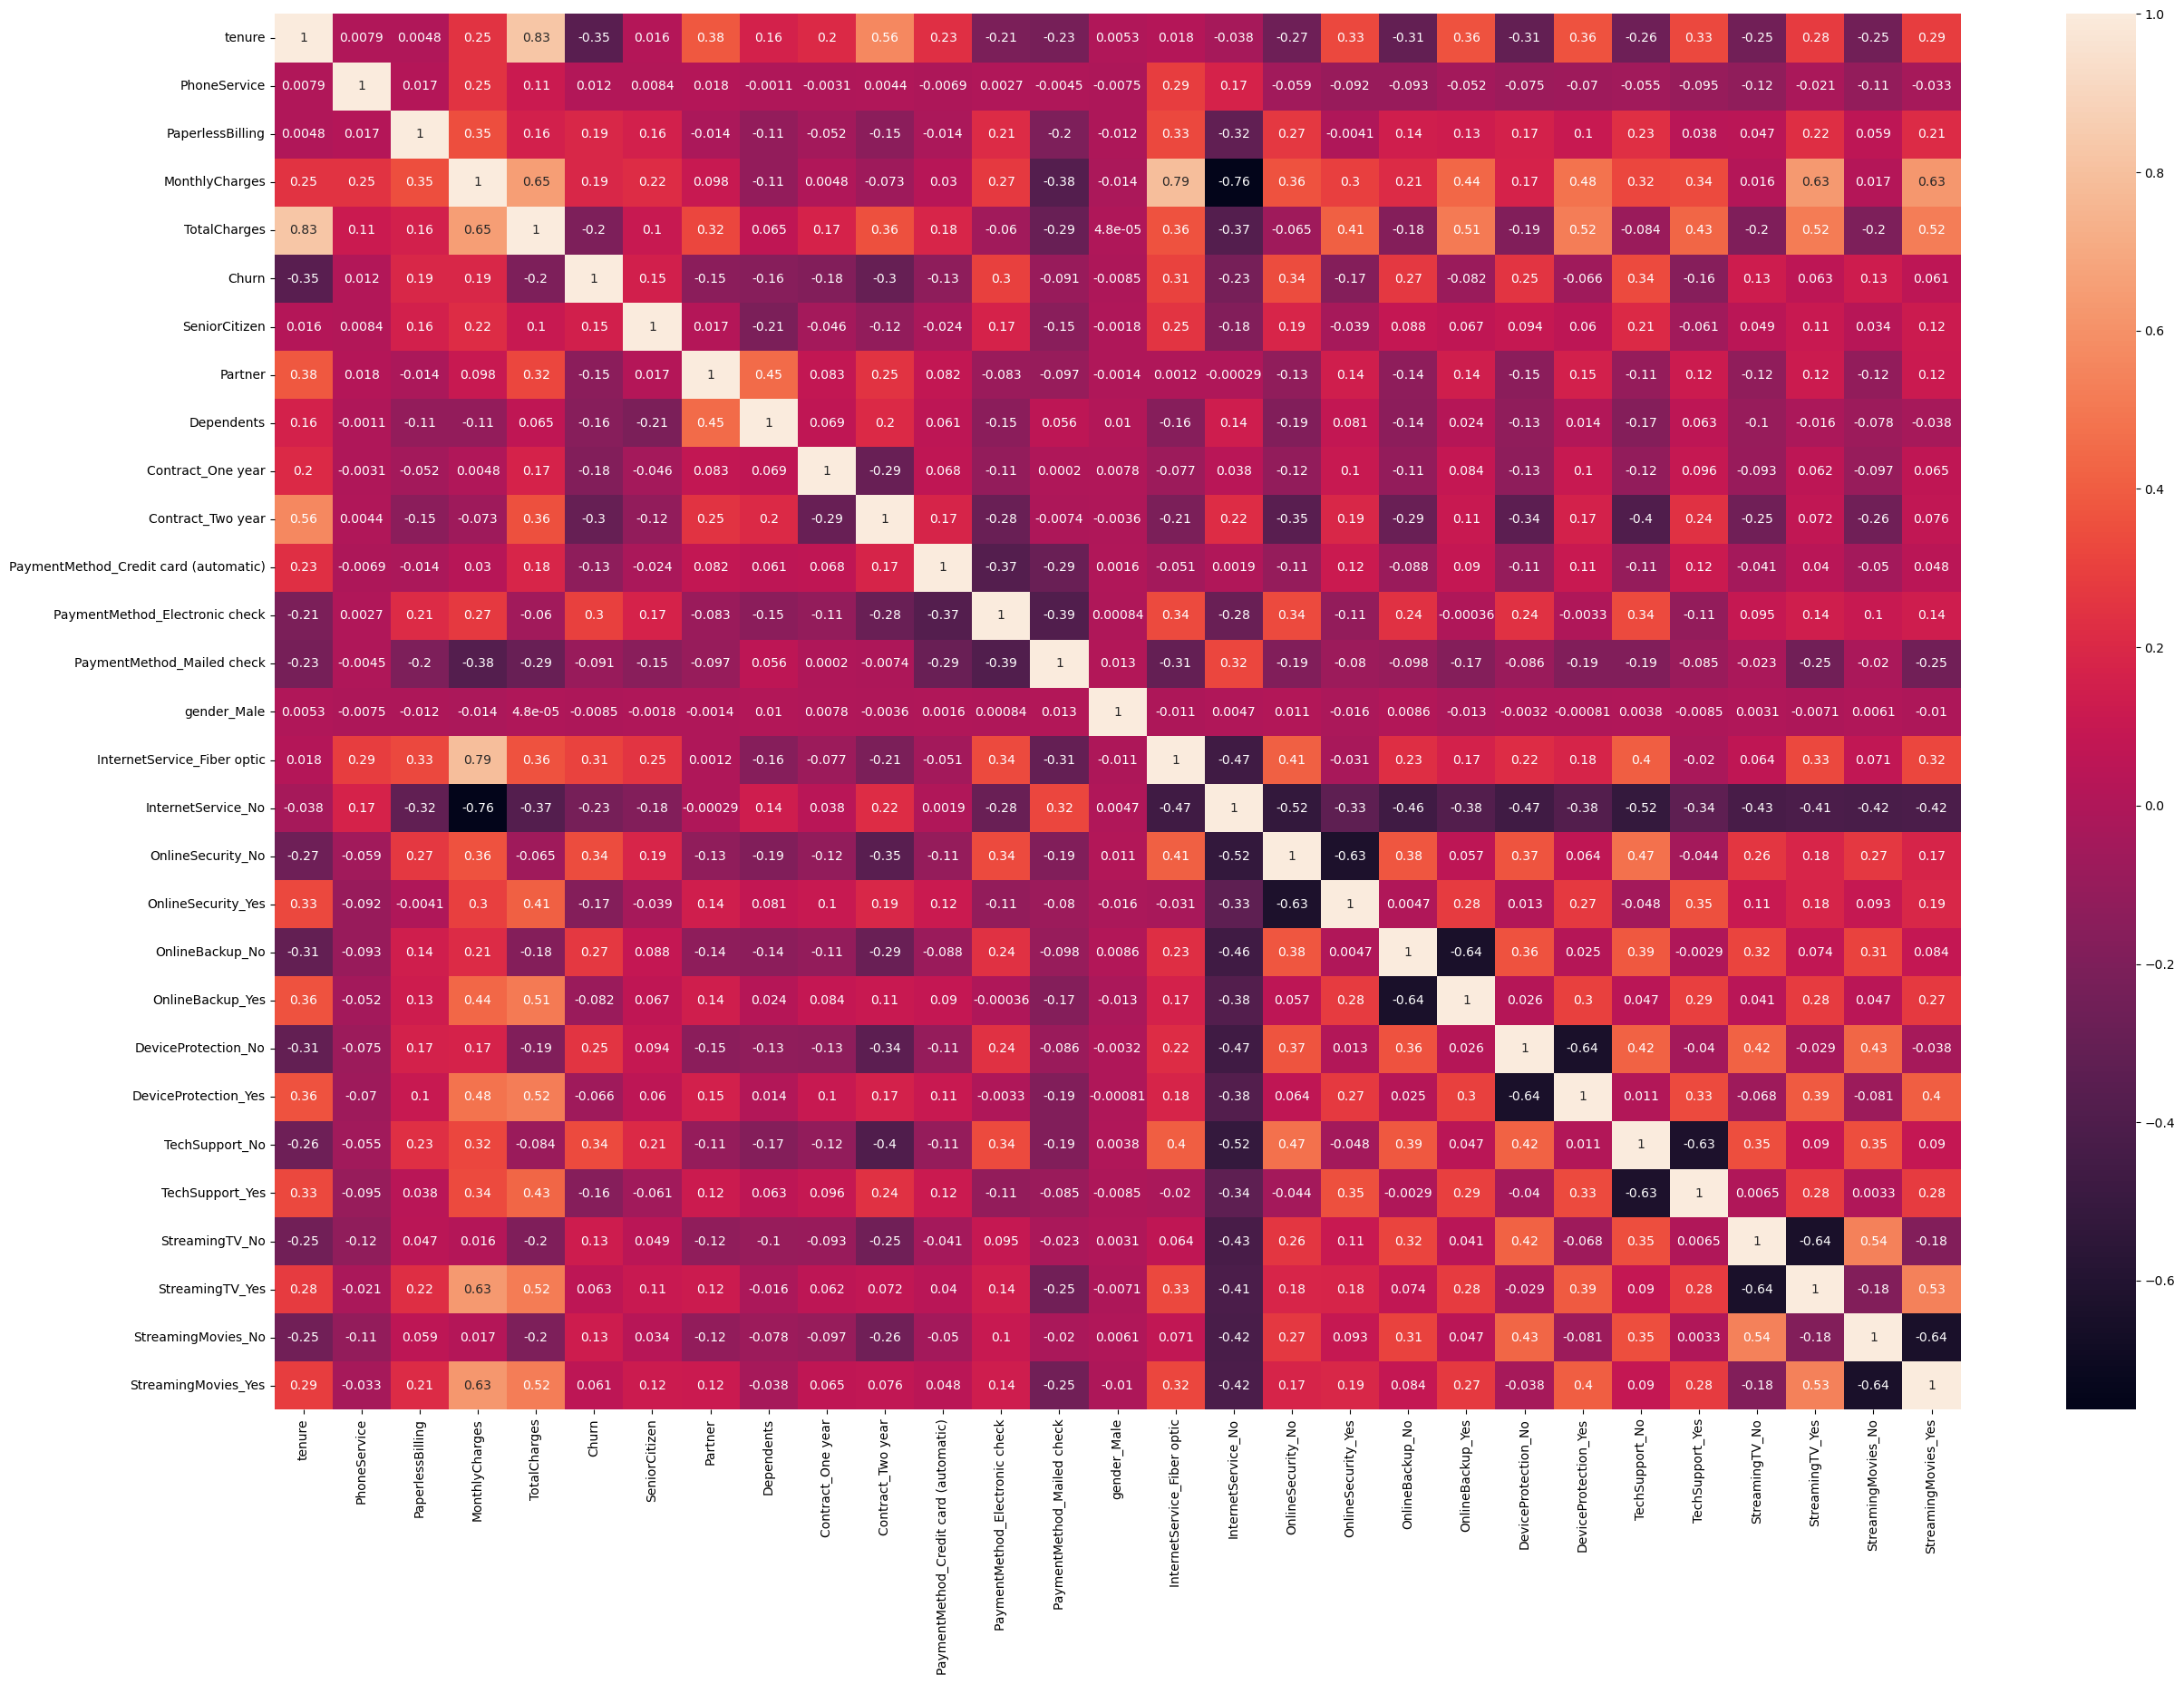

In [68]:
plt.figure(figsize=(30,20))
sns.heatmap(telecom.corr(numeric_only=True),annot=True)
plt.show()

In [69]:
X_test = X_test.drop(['MultipleLines_No','OnlineSecurity_No','OnlineBackup_No','DeviceProtection_No','TechSupport_No',
                       'StreamingTV_No','StreamingMovies_No'], axis=1)
X_train = X_train.drop(['MultipleLines_No','OnlineSecurity_No','OnlineBackup_No','DeviceProtection_No','TechSupport_No',
                         'StreamingTV_No','StreamingMovies_No'], axis=1)

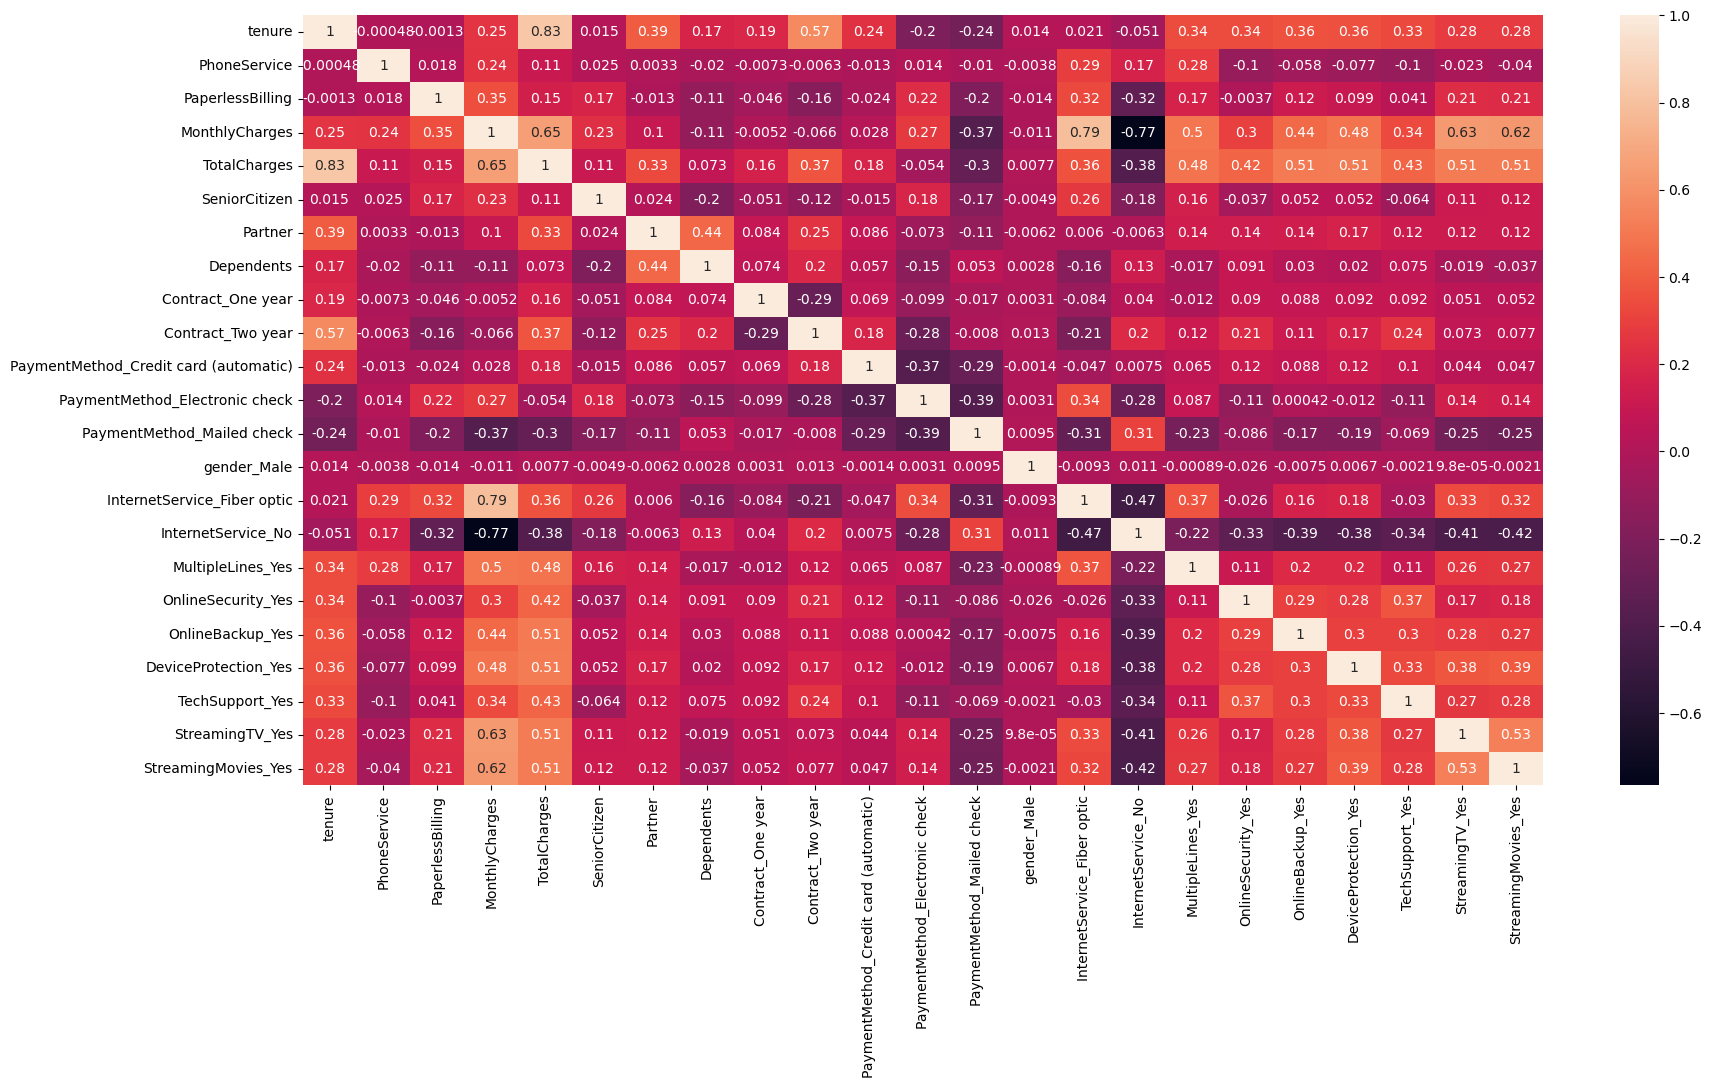

In [70]:
plt.figure(figsize=(20,10))
sns.heatmap(X_train.corr(),annot=True)
plt.show()

### Train the model!

In [71]:
import statsmodels.api as sm

In [72]:
X_train = X_train.astype(float)
y_train = y_train.astype(float)

In [73]:
X_train.dtypes

tenure                                   float64
PhoneService                             float64
PaperlessBilling                         float64
MonthlyCharges                           float64
TotalCharges                             float64
SeniorCitizen                            float64
Partner                                  float64
Dependents                               float64
Contract_One year                        float64
Contract_Two year                        float64
PaymentMethod_Credit card (automatic)    float64
PaymentMethod_Electronic check           float64
PaymentMethod_Mailed check               float64
gender_Male                              float64
InternetService_Fiber optic              float64
InternetService_No                       float64
MultipleLines_Yes                        float64
OnlineSecurity_Yes                       float64
OnlineBackup_Yes                         float64
DeviceProtection_Yes                     float64
TechSupport_Yes     

1️⃣ sm.GLM(...)

GLM = Generalized Linear Model

Logistic regression is a type of GLM.

In [74]:
logml = sm.GLM(y_train, sm.add_constant(X_train), family=sm.families.Binomial())
result = logml.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 4922
Model:                            GLM   Df Residuals:                     4898
Model Family:                Binomial   Df Model:                           23
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2004.7
Date:                Thu, 26 Mar 2026   Deviance:                       4009.4
Time:                        10:20:07   Pearson chi2:                 6.07e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2844
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -3.9382      1.546     -2.547      0.011      -6.969      -0.908
tenure                                   -1.5172      0.189     -8.015      0.000      -1.888      -1.146
PhoneService                              0.9507      0.789      1.205      0.228      -0.595       2.497
PaperlessBilling                          0.3254      0.090      3.614      0.000       0.149       0.502
MonthlyCharges                           -2.1806      1.160     -1.880      0.060      -4.454       0.092
TotalCharges                              0.7332      0.198      3.705      0.000       0.345       1.121
SeniorCitizen                             0.3984      0.102      3.924      0.000       0.199       0.597
Partner                                   0.0374      0.094      0.399      0.690      -0.146       0.221
Dependents                               -0.1430      0.107     -1.332      0.183      -0.353       0.067
Contract_One year                        -0.6578      0.129     -5.106      0.000      -0.910      -0.405
Contract_Two year                        -1.2455      0.212     -5.874      0.000      -1.661      -0.830
PaymentMethod_Credit card (automatic)    -0.2577      0.137     -1.883      0.060      -0.526       0.011
PaymentMethod_Electronic check            0.1615      0.113      1.434      0.152      -0.059       0.382
PaymentMethod_Mailed check               -0.2536      0.137     -1.845      0.065      -0.523       0.016
gender_Male                              -0.0346      0.078     -0.442      0.658      -0.188       0.119
InternetService_Fiber optic               2.5124      0.967      2.599      0.009       0.618       4.407
InternetService_No                       -2.7792      0.982     -2.831      0.005      -4.703      -0.855
MultipleLines_Yes                         0.5623      0.214      2.628      0.009       0.143       0.982
OnlineSecurity_Yes                       -0.0245      0.216     -0.113      0.910      -0.448       0.399
OnlineBackup_Yes                          0.1740      0.212      0.822      0.411      -0.241       0.589
DeviceProtection_Yes                      0.3229      0.215      1.501      0.133      -0.099       0.744
TechSupport_Yes                          -0.0305      0.216     -0.141      0.888      -0.455       0.394
StreamingTV_Yes                           0.9598      0.396      2.423      0.015       0.183       1.736
StreamingMovies_Yes                       0.8484      0.396      2.143      0.032       0.072       1.624
=========================================================================================================
"""

p-value tells:

👉 “How likely is this result just by luck?”

### Step-8 Feature selection using RFE

In [75]:
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression()

In [76]:
from sklearn.feature_selection import RFE

rfe = RFE(estimator=logreg, n_features_to_select=15)

rfe = rfe.fit(X_train, y_train)


In [77]:
rfe.support_

array([ True, False,  True,  True,  True,  True, False, False,  True,
        True,  True, False,  True, False,  True,  True,  True, False,
       False, False,  True,  True,  True])

In [78]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('tenure', np.True_, np.int64(1)),
 ('PhoneService', np.False_, np.int64(3)),
 ('PaperlessBilling', np.True_, np.int64(1)),
 ('MonthlyCharges', np.True_, np.int64(1)),
 ('TotalCharges', np.True_, np.int64(1)),
 ('SeniorCitizen', np.True_, np.int64(1)),
 ('Partner', np.False_, np.int64(7)),
 ('Dependents', np.False_, np.int64(6)),
 ('Contract_One year', np.True_, np.int64(1)),
 ('Contract_Two year', np.True_, np.int64(1)),
 ('PaymentMethod_Credit card (automatic)', np.True_, np.int64(1)),
 ('PaymentMethod_Electronic check', np.False_, np.int64(4)),
 ('PaymentMethod_Mailed check', np.True_, np.int64(1)),
 ('gender_Male', np.False_, np.int64(8)),
 ('InternetService_Fiber optic', np.True_, np.int64(1)),
 ('InternetService_No', np.True_, np.int64(1)),
 ('MultipleLines_Yes', np.True_, np.int64(1)),
 ('OnlineSecurity_Yes', np.False_, np.int64(2)),
 ('OnlineBackup_Yes', np.False_, np.int64(5)),
 ('DeviceProtection_Yes', np.False_, np.int64(9)),
 ('TechSupport_Yes', np.True_, np.int64(1)),
 ('

In [79]:
col=X_train.columns[rfe.support_]
print(col)

Index(['tenure', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'SeniorCitizen', 'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check',
       'InternetService_Fiber optic', 'InternetService_No',
       'MultipleLines_Yes', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_Yes'],
      dtype='object')


In [80]:
X_train.columns[~rfe.support_]

Index(['PhoneService', 'Partner', 'Dependents',
       'PaymentMethod_Electronic check', 'gender_Male', 'OnlineSecurity_Yes',
       'OnlineBackup_Yes', 'DeviceProtection_Yes'],
      dtype='object')

In [81]:
X_train_sm=sm.add_constant(X_train[col])
logm2=sm.GLM(y_train,X_train_sm,family=sm.families.Binomial())
res=logm2.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 4922
Model:                            GLM   Df Residuals:                     4906
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2011.1
Date:                Thu, 26 Mar 2026   Deviance:                       4022.2
Time:                        10:20:08   Pearson chi2:                 6.25e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2825
Covariance Type:            nonrobust                                         
=========================================================================================================
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                    -2.2462      0.189    -11.879      0.000      -2.617      -1.876
tenure                                   -1.5596      0.187     -8.334      0.000      -1.926      -1.193
PaperlessBilling                          0.3436      0.090      3.832      0.000       0.168       0.519
MonthlyCharges                           -0.9692      0.199     -4.878      0.000      -1.359      -0.580
TotalCharges                              0.7421      0.197      3.764      0.000       0.356       1.128
SeniorCitizen                             0.4296      0.100      4.312      0.000       0.234       0.625
Contract_One year                        -0.6830      0.128     -5.342      0.000      -0.934      -0.432
Contract_Two year                        -1.2931      0.211     -6.138      0.000      -1.706      -0.880
PaymentMethod_Credit card (automatic)    -0.3724      0.113     -3.308      0.001      -0.593      -0.152
PaymentMethod_Mailed check               -0.3723      0.111     -3.345      0.001      -0.591      -0.154
InternetService_Fiber optic               1.5865      0.216      7.342      0.000       1.163       2.010
InternetService_No                       -1.6897      0.216     -7.830      0.000      -2.113      -1.267
MultipleLines_Yes                         0.3779      0.104      3.640      0.000       0.174       0.581
TechSupport_Yes                          -0.2408      0.109     -2.210      0.027      -0.454      -0.027
StreamingTV_Yes                           0.5796      0.114      5.102      0.000       0.357       0.802
StreamingMovies_Yes                       0.4665      0.111      4.197      0.000       0.249       0.684
=========================================================================================================
"""

In [82]:
y_train_pred=res.predict(X_train_sm)
y_train_pred[:10]

879     0.192642
5790    0.275624
6498    0.599507
880     0.513571
2784    0.648233
3874    0.414846
5387    0.431184
6623    0.801788
4465    0.228194
5364    0.504575
dtype: float64

In [83]:
y_train_pred_final=pd.DataFrame({"Churn":y_train.values,"Churn_prob":y_train_pred})
y_train_pred_final["CustID"]=y_train.index
y_train_pred_final.head()

,Churn,Churn_prob,CustID
879,0.0,0.192642,879
5790,0.0,0.275624,5790
6498,1.0,0.599507,6498
880,1.0,0.513571,880
2784,1.0,0.648233,2784


In [84]:
y_train_pred_final["Predicted"]=y_train_pred_final.Churn_prob.apply(lambda x:1 if x>0.5 else 0)
y_train_pred_final.head()

,Churn,Churn_prob,CustID,Predicted
879,0.0,0.192642,879,0
5790,0.0,0.275624,5790,0
6498,1.0,0.599507,6498,1
880,1.0,0.513571,880,1
2784,1.0,0.648233,2784,1


In [85]:
from sklearn import metrics 

In [86]:
confusion=metrics.confusion_matrix(y_train_pred_final.Churn,y_train_pred_final.Predicted)
print(confusion)

[[3275  360]
 [ 574  713]]


In [87]:
#predicted  not_churn  churn
#actual  
#not_churn  3275        360
#churn       574        713 
#[[TN  FP]
#[FN  TP]]


In [88]:
print(metrics.accuracy_score(y_train_pred_final.Churn,y_train_pred_final.Predicted))

0.8102397399431126


### Checking VIF's

In [89]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [90]:
vif = pd.DataFrame()
vif['Features'] = X_train[col].columns
for i in range(X_train[col].shape[1]):
    vif['VIF'] = variance_inflation_factor(X_train[col].values, i)
    vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,tenure,2.79
1,PaperlessBilling,2.79
2,MonthlyCharges,2.79
3,TotalCharges,2.79
4,SeniorCitizen,2.79
5,Contract_One year,2.79
6,Contract_Two year,2.79
7,PaymentMethod_Credit card (automatic),2.79
8,PaymentMethod_Mailed check,2.79
9,InternetService_Fiber optic,2.79


### Metics beyond simple accuracy

In [91]:
TP=confusion[1,1]
FP=confusion[0,1]
TN=confusion[0,0]
FN=confusion[1,0]

In [92]:
#Sensitivity(Recall)
print(TP/float(TP+FN))

0.554001554001554


In [93]:
#Specificity
print(TN/(FP+TN))

0.9009628610729024


In [94]:
y_train_pred_final.to_csv("churn_probabilities.csv")

### Plotting the ROC curve

In [95]:
def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

In [96]:
fpr, tpr, thresholds = metrics.roc_curve( y_train_pred_final.Churn, y_train_pred_final.Churn_prob, drop_intermediate = False )

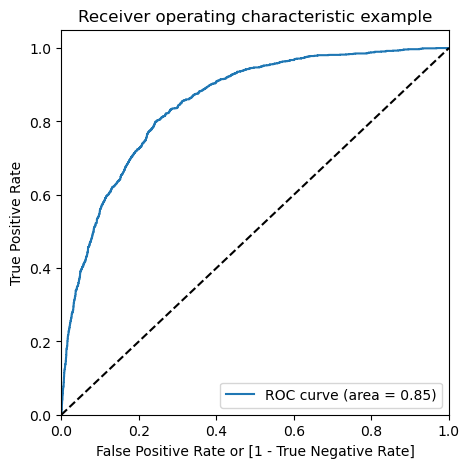

In [97]:
draw_roc(y_train_pred_final.Churn, y_train_pred_final.Churn_prob)

In [98]:
y_train_pred_final.columns

Index(['Churn', 'Churn_prob', 'CustID', 'Predicted'], dtype='object')

### Finding Optimal Cutoff(Threshold)

In [99]:
# Let's create columns with different probability cutoffs 
numbers = [float(x)/10 for x in range(10)]
for i in numbers:
    y_train_pred_final[i]= y_train_pred_final.Churn_prob.map(lambda x: 1 if x > i else 0)
y_train_pred_final.head()

,Churn,Churn_prob,CustID,Predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
879,0.0,0.192642,879,0,1,1,0,0,0,0,0,0,0,0
5790,0.0,0.275624,5790,0,1,1,1,0,0,0,0,0,0,0
6498,1.0,0.599507,6498,1,1,1,1,1,1,1,0,0,0,0
880,1.0,0.513571,880,1,1,1,1,1,1,1,0,0,0,0
2784,1.0,0.648233,2784,1,1,1,1,1,1,1,1,0,0,0


In [100]:
# Now let's calculate accuracy sensitivity and specificity for various probability cutoffs.
cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])
from sklearn.metrics import confusion_matrix

# TP = confusion[1,1] # true positive 
# TN = confusion[0,0] # true negatives
# FP = confusion[0,1] # false positives
# FN = confusion[1,0] # false negatives

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    cm1 = metrics.confusion_matrix(y_train_pred_final.Churn, y_train_pred_final[i] )
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1
    
    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])
    cutoff_df.loc[i] =[ i ,accuracy,sensi,speci]
print(cutoff_df)

     prob  accuracy     sensi     speci
0.0   0.0  0.261479  1.000000  0.000000
0.1   0.1  0.619057  0.946387  0.503164
0.2   0.2  0.716782  0.867133  0.663549
0.3   0.3  0.771231  0.777001  0.769188
0.4   0.4  0.792767  0.672106  0.835488
0.5   0.5  0.810240  0.554002  0.900963
0.6   0.6  0.804145  0.393162  0.949656
0.7   0.7  0.778342  0.195804  0.984594
0.8   0.8  0.747257  0.039627  0.997799
0.9   0.9  0.738521  0.000000  1.000000


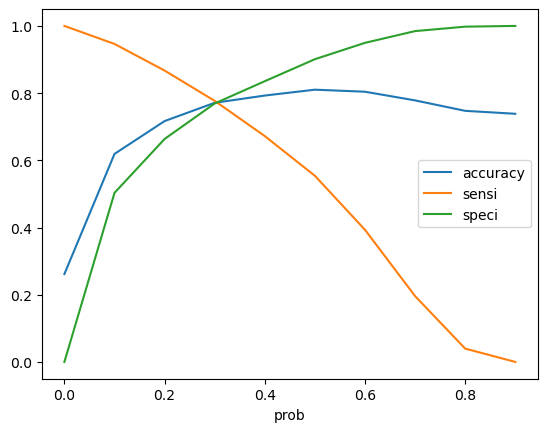

In [101]:
# Let's plot accuracy sensitivity and specificity for various probabilities.
cutoff_df.plot.line(x='prob', y=['accuracy','sensi','speci'])
plt.show()

In [102]:
#from the above graph u can see that the accuracy,sensi,specifi is around 7.8 or 7.9 and the probability or cutoff is 0.3 

In [103]:
y_train_pred_final['final_predicted'] = y_train_pred_final.Churn_prob.map( lambda x: 1 if x > 0.3 else 0)

y_train_pred_final.head()

,Churn,Churn_prob,CustID,Predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,final_predicted
879,0.0,0.192642,879,0,1,1,0,0,0,0,0,0,0,0,0
5790,0.0,0.275624,5790,0,1,1,1,0,0,0,0,0,0,0,0
6498,1.0,0.599507,6498,1,1,1,1,1,1,1,0,0,0,0,1
880,1.0,0.513571,880,1,1,1,1,1,1,1,0,0,0,0,1
2784,1.0,0.648233,2784,1,1,1,1,1,1,1,1,0,0,0,1


In [104]:
# Let's check the overall accuracy.
metrics.accuracy_score(y_train_pred_final.Churn, y_train_pred_final.final_predicted)

0.7712312068264933

In [105]:
confusion2 = metrics.confusion_matrix(y_train_pred_final.Churn, y_train_pred_final.final_predicted )
confusion2

array([[2796,  839],
       [ 287, 1000]])

In [106]:
TP = confusion2[1,1] # true positive 
TN = confusion2[0,0] # true negatives
FP = confusion2[0,1] # false positives
FN = confusion2[1,0] # false negatives

In [107]:
# Let's see the sensitivity of our logistic regression model
TP / float(TP+FN)

np.float64(0.777000777000777)

### Precision and recall

In [108]:
confusion = metrics.confusion_matrix(y_train_pred_final.Churn, y_train_pred_final.Predicted)
confusion

array([[3275,  360],
       [ 574,  713]])

In [109]:
y_train_pred_final.columns

Index([          'Churn',      'Churn_prob',          'CustID',
             'Predicted',               0.0,               0.1,
                     0.2,               0.3,               0.4,
                     0.5,               0.6,               0.7,
                     0.8,               0.9, 'final_predicted'],
      dtype='object')

In [110]:
TP = confusion[1,1] # true positive 
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [111]:
#Precision[[TP/TP+FP]]
TP/float(TP+FP)

np.float64(0.6644920782851818)

In [112]:
#Recall[[TP/TP+FN]]
TP/float(TP+FN)

np.float64(0.554001554001554)

### Using sklearn utilities

In [113]:
from sklearn.metrics import precision_score, recall_score

In [114]:
precision_score(y_train_pred_final.Churn, y_train_pred_final.Predicted)

0.6644920782851818

In [115]:
recall_score(y_train_pred_final.Churn, y_train_pred_final.Predicted)

0.554001554001554

### Precision and recall tradeoff

In [116]:
from sklearn.metrics import precision_recall_curve

In [117]:
y_train_pred_final.Churn, y_train_pred_final.Predicted

(879     0.0
 5790    0.0
 6498    1.0
 880     1.0
 2784    1.0
        ... 
 79      0.0
 3934    0.0
 5964    0.0
 6947    0.0
 5649    0.0
 Name: Churn, Length: 4922, dtype: float64,
 879     0
 5790    0
 6498    1
 880     1
 2784    1
        ..
 79      0
 3934    0
 5964    0
 6947    0
 5649    0
 Name: Predicted, Length: 4922, dtype: int64)

In [118]:
p, r, thresholds = precision_recall_curve(y_train_pred_final.Churn, y_train_pred_final.Churn_prob)

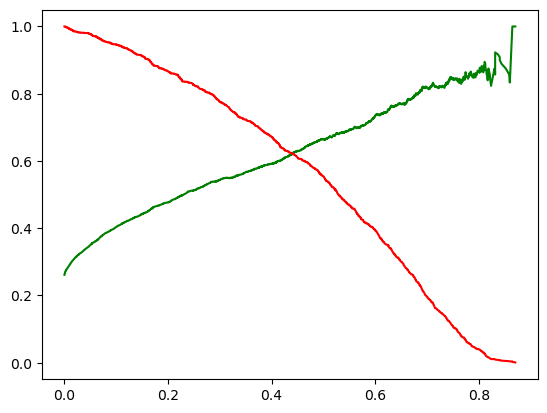

In [119]:
plt.plot(thresholds, p[:-1], "g-")
plt.plot(thresholds, r[:-1], "r-")
plt.show()

### Making predictions on the test set

In [120]:
X_test[['tenure','MonthlyCharges','TotalCharges']] = scaler.transform(X_test[['tenure','MonthlyCharges','TotalCharges']])

In [121]:
X_test = X_test[col]
X_test.head()

,tenure,PaperlessBilling,MonthlyCharges,TotalCharges,SeniorCitizen,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,MultipleLines_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes
942,-0.347623,1,0.499951,-0.128378,0,0,0,1,0,1,0,False,0,0,1
3730,0.999203,1,1.319685,1.600302,0,0,0,1,0,1,0,1,0,1,1
1761,1.040015,1,-1.342374,-0.343297,0,0,1,1,0,0,1,1,0,0,0
2283,-1.286319,1,0.223935,-0.979170,0,0,0,0,1,1,0,False,0,0,0
1872,0.346196,0,-1.500335,-0.656086,0,0,1,0,0,0,1,False,0,0,0


In [122]:
X_test_sm = sm.add_constant(X_test)

In [124]:
X_test_sm.dtypes

const                                    float64
tenure                                   float64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
SeniorCitizen                              int64
Contract_One year                          int64
Contract_Two year                          int64
PaymentMethod_Credit card (automatic)      int64
PaymentMethod_Mailed check                 int64
InternetService_Fiber optic                int64
InternetService_No                         int64
MultipleLines_Yes                         object
TechSupport_Yes                            int64
StreamingTV_Yes                            int64
StreamingMovies_Yes                        int64
dtype: object

In [125]:
X_test_sm = X_test_sm.astype(float)

In [126]:
y_test_pred = res.predict(X_test_sm)

In [127]:
y_test_pred[:10]

942     0.435436
3730    0.286097
1761    0.004253
2283    0.592438
1872    0.008149
1970    0.690309
2532    0.287089
1616    0.004133
2485    0.583534
5914    0.119703
dtype: float64

In [128]:
# Converting y_pred to a dataframe which is an array
y_pred_1 = pd.DataFrame(y_test_pred)

In [129]:
# Let's see the head
y_pred_1.head()

,0
942,0.435436
3730,0.286097
1761,0.004253
2283,0.592438
1872,0.008149


In [130]:
# Converting y_test to dataframe
y_test_df = pd.DataFrame(y_test)

In [131]:
# Putting CustID to index
y_test_df['CustID'] = y_test_df.index

In [132]:
# Removing index for both dataframes to append them side by side 
y_pred_1.reset_index(drop=True, inplace=True)
y_test_df.reset_index(drop=True, inplace=True)

In [133]:
# Appending y_test_df and y_pred_1
y_pred_final = pd.concat([y_test_df, y_pred_1],axis=1)

In [134]:
y_pred_final.head()

,Churn,CustID,0
0,0,942,0.435436
1,1,3730,0.286097
2,0,1761,0.004253
3,1,2283,0.592438
4,0,1872,0.008149


In [135]:
# Renaming the column 
y_pred_final= y_pred_final.rename(columns={ 0 : 'Churn_Prob'})

In [137]:
# Rearranging the columns
y_pred_final = y_pred_final.reindex(['CustID','Churn','Churn_Prob'], axis=1)

In [138]:
# Let's see the head of y_pred_final
y_pred_final.head()

,CustID,Churn,Churn_Prob
0,942,0,0.435436
1,3730,1,0.286097
2,1761,0,0.004253
3,2283,1,0.592438
4,1872,0,0.008149


In [141]:
y_pred_final['final_predicted'] = y_pred_final.Churn_Prob.map(lambda x: 1 if x > 0.3 else 0)

In [140]:
y_pred_final.head()

,CustID,Churn,Churn_Prob,final_predicted
0,942,0,0.435436,1
1,3730,1,0.286097,0
2,1761,0,0.004253,0
3,2283,1,0.592438,1
4,1872,0,0.008149,0


In [142]:
# Let's check the overall accuracy.
metrics.accuracy_score(y_pred_final.Churn, y_pred_final.final_predicted)

0.7464454976303317

In [143]:
confusion2 = metrics.confusion_matrix(y_pred_final.Churn, y_pred_final.final_predicted )
confusion2

array([[1144,  384],
       [ 151,  431]])

In [144]:
TP = confusion2[1,1] # true positive 
TN = confusion2[0,0] # true negatives
FP = confusion2[0,1] # false positives
FN = confusion2[1,0] # false negatives

In [145]:
# Let's see the sensitivity of our logistic regression model
TP / float(TP+FN)

np.float64(0.7405498281786942)

In [146]:
# Let us calculate specificity
TN / float(TN+FP)

np.float64(0.7486910994764397)